Here, we demonstrate that the adverserial training removes the relevant categorical information from the bias term:

In [1]:
import os

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from sklearn.metrics import normalized_mutual_info_score
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_prediction, adata_dimviz_bias


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import embed_tf_activity

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

author = 'Kang'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [5]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

trainer_na = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_no_adverserial_trainer.pickle'))
mod_na = trainer_na.mod

In [6]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

In [8]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

First, let's see what the loss looks like across epochs:

In [9]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df_na = trainer_na.stats['train'].copy()

# train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

/tmp/ipykernel_1036254/611112872.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_1036254/611112872.py:46: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
/tmp/ipykernel_1036254/611112872.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
/tmp/ipykernel_1036254/611112872.py:73: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])


''

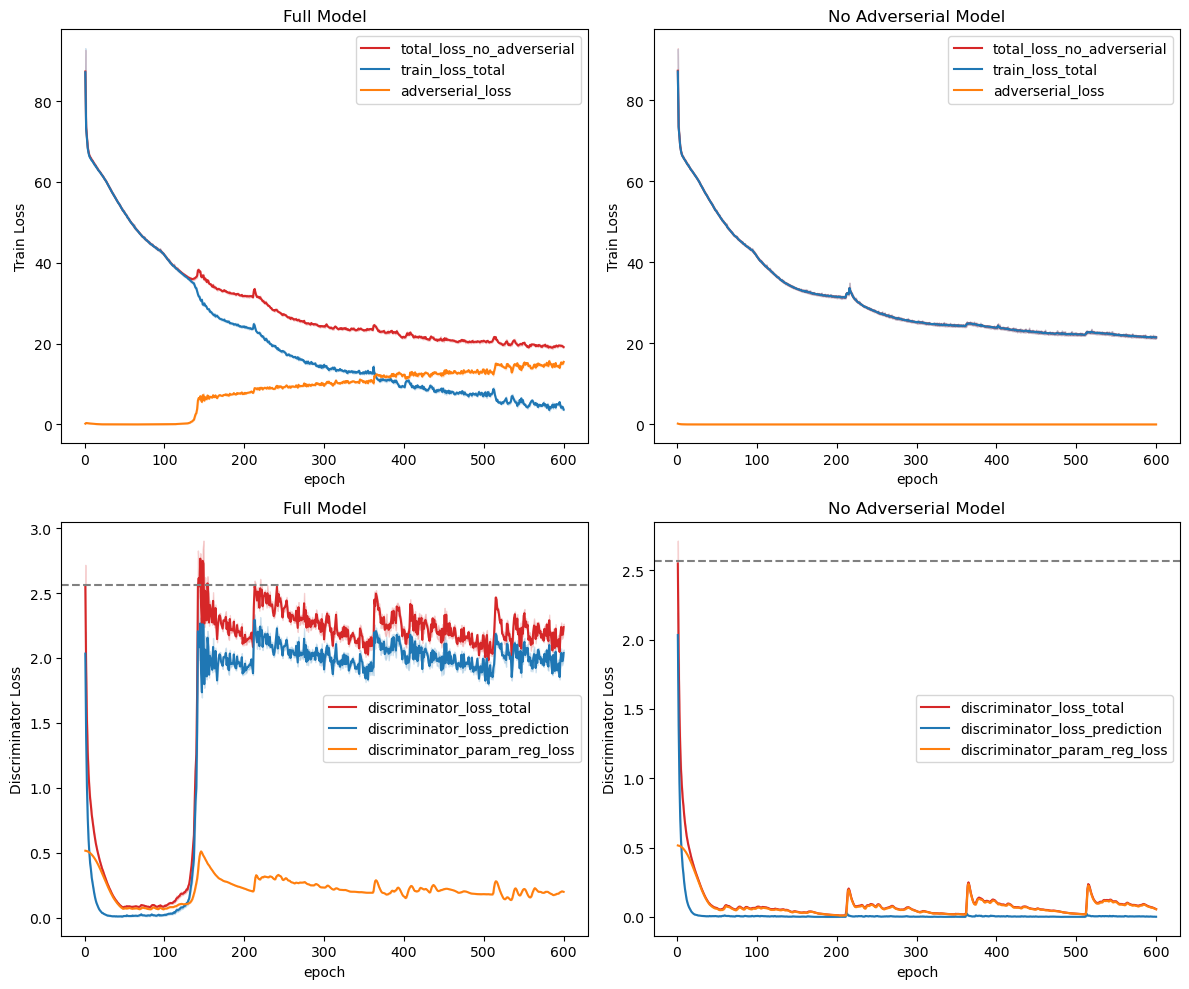

In [10]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 2: model no adverserial, adverserial loss
viz_df = train_stats_df_na[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[1].set_ylabel('Train Loss')
ax[1].set_title('No Adverserial Model')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

# Plot 4: model no adverserial, discriminator loss
viz_df = train_stats_df_na[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[3].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[3].legend(loc='best')
ax[3].set_ylabel('Discriminator Loss')
ax[3].set_title('No Adverserial Model')


fig.tight_layout()
;


Next, let's see what the global bias looks like in UMAP space. To do this, we run the following prediction: for each condition (stimulation + cell type), we predict what that cell type would look like in the opposite stimulation condition from ALL the in-distribution data (from all other conditions). 

Get predictions for counterfactuals:

In [11]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

In [14]:
# mod.signaling_network.vae.seed = seed
# mod_na.signaling_network.vae.seed = seed

In [15]:
biases_res = {}
for counterfactual_type in ['opposite', 'in_distribution']:
    biases_res[counterfactual_type] = {}
    biases = get_prediction(mod = mod, 
                            tf_adata = tf_adata, 
                            counterfactual_type = counterfactual_type, 
                            cf_map = cf_map, 
                            train_cells_all = train_cells_all, 
                            test_conds = test_conds,
                            remove_type = 'none',
                            return_bias = True, 
                           return_loss = False)
    bias_global, bias_mu, bias_sigma, bias_cats, bias_tot, obs = biases

    biases_na = get_prediction(mod = mod_na, 
                               tf_adata = tf_adata, 
                               counterfactual_type = counterfactual_type, 
                               cf_map = cf_map, 
                               train_cells_all = train_cells_all, 
                               test_conds = test_conds, 
                               remove_type = 'none',
                               return_bias = True, 
                              return_loss = False)
    bias_global_na, _, _, _,_, _ = biases_na
    
    biases_res[counterfactual_type]['no_adverserial'] = bias_global_na
    biases_res[counterfactual_type]['adverserial'] = (bias_global, bias_mu, bias_sigma, bias_cats, bias_tot)
    biases_res[counterfactual_type]['obs'] = obs    
    
    del _, biases_na, biases
    torch.cuda.empty_cache()



Clustering and dimensionality reduction:

In [17]:
# biases_clustered = {}

# for counterfactual_type, br in biases_res.items():
#     print(counterfactual_type)
#     bias_global_na = br['no_adverserial']
#     bias_global, _, _, bias_cats, bias_tot = br['adverserial']
#     obs = br['obs']
    
#     # no adverserial
#     bias_global_na = sc.AnnData(X = bias_global_na.detach().cpu().numpy(), obs = obs)
#     embed_tf_activity(bias_global_na, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

#     # full model
#     bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
#     embed_tf_activity(bias_global, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

#     # full model -- categorical information added
#     bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
#     embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
    
#     # full model -- categorical information only
#     bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
#     embed_tf_activity(bias_cats, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
    
#     biases_clustered[counterfactual_type] = (bias_global_na, bias_global, bias_tot, bias_cats)

# io.write_pickled_object(biases_clustered, 
#                        os.path.join(data_path, 'interim', author + '_clustered_biases.pickle'))

biases_clustered = io.read_pickled_object(os.path.join(data_path, 'interim', author + '_clustered_biases.pickle'))

opposite


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:311: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata, resolution = resolution) # cluster
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS

in_distribution


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use n

Let's visualizee the opposit counterfactual first.

In [66]:
counterfactual_type = 'opposite'
bias_global_na, bias_global, bias_tot, _ = biases_clustered[counterfactual_type]

In [67]:
# adata_types = ['Perfectly Separated', 'Perfectly Mixed', 
#                      'Model No Adverserial', 'Model with Adverserial', None, 
#               'Model with Adverserial - Categorical Information Added']
# adata_dict = dict(zip(adata_types, 
#                      [one_hot, rand, bias_adata_na, bias_adata, None, bias_tot]))


adata_types = ['Model No Adverserial', 'Model with Adverserial', 'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [bias_global_na, bias_global,bias_tot]))

The top left panel is clustering/dimreduction results on one-hot encodings of the predicted cell types. The top right panel is this same information, but with the barcodes permuted. These reppresent baseline NMI values from the clustering pipeline. 

''

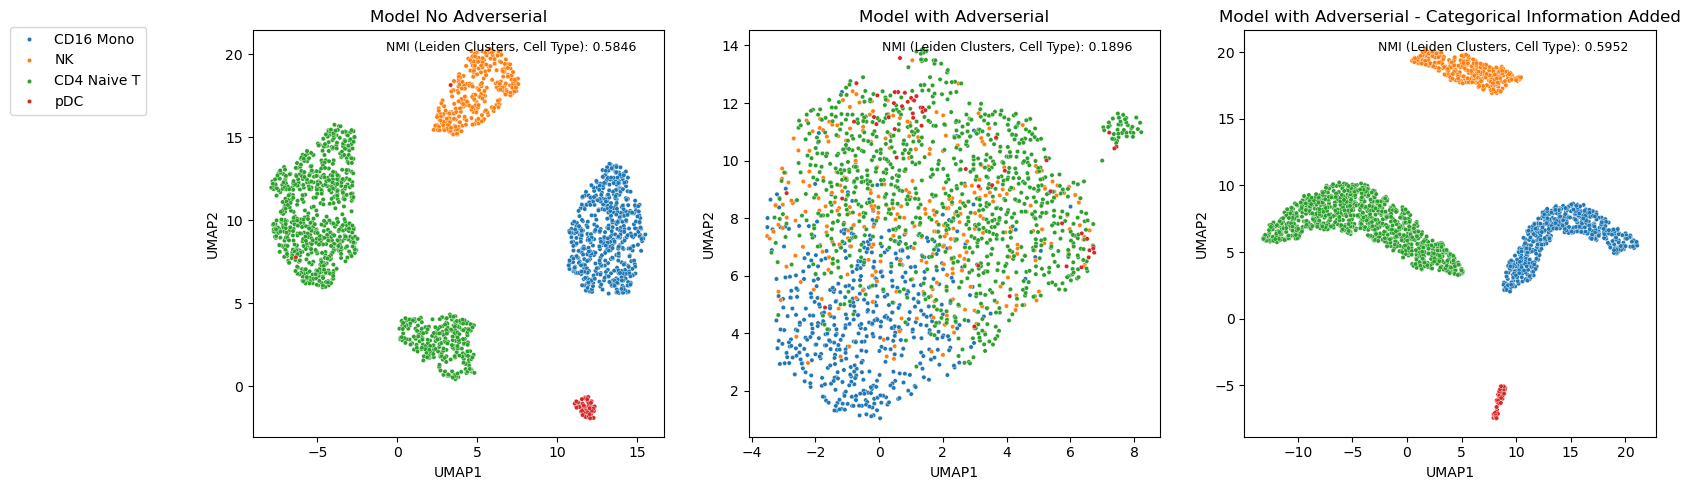

In [70]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))
ax = ax.flatten()

subset_size = None
for i, (adata_type, adata) in enumerate(adata_dict.items()):
    if adata is not None:
        viz_df, nmi = adata_dimviz_bias(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                             subset_size = subset_size)
        

        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                        s=10,
                        ax = ax[i])
        ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i].set_title(adata_type)
    else:
        ax[i].axis('off')

lines, labels = ax[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
fig.tight_layout()
;

Let's also look at the distributions of the values:

In [43]:
bias_global, bias_mu, bias_sigma, bias_cats, bias_tot = biases_res[counterfactual_type]['adverserial']

''

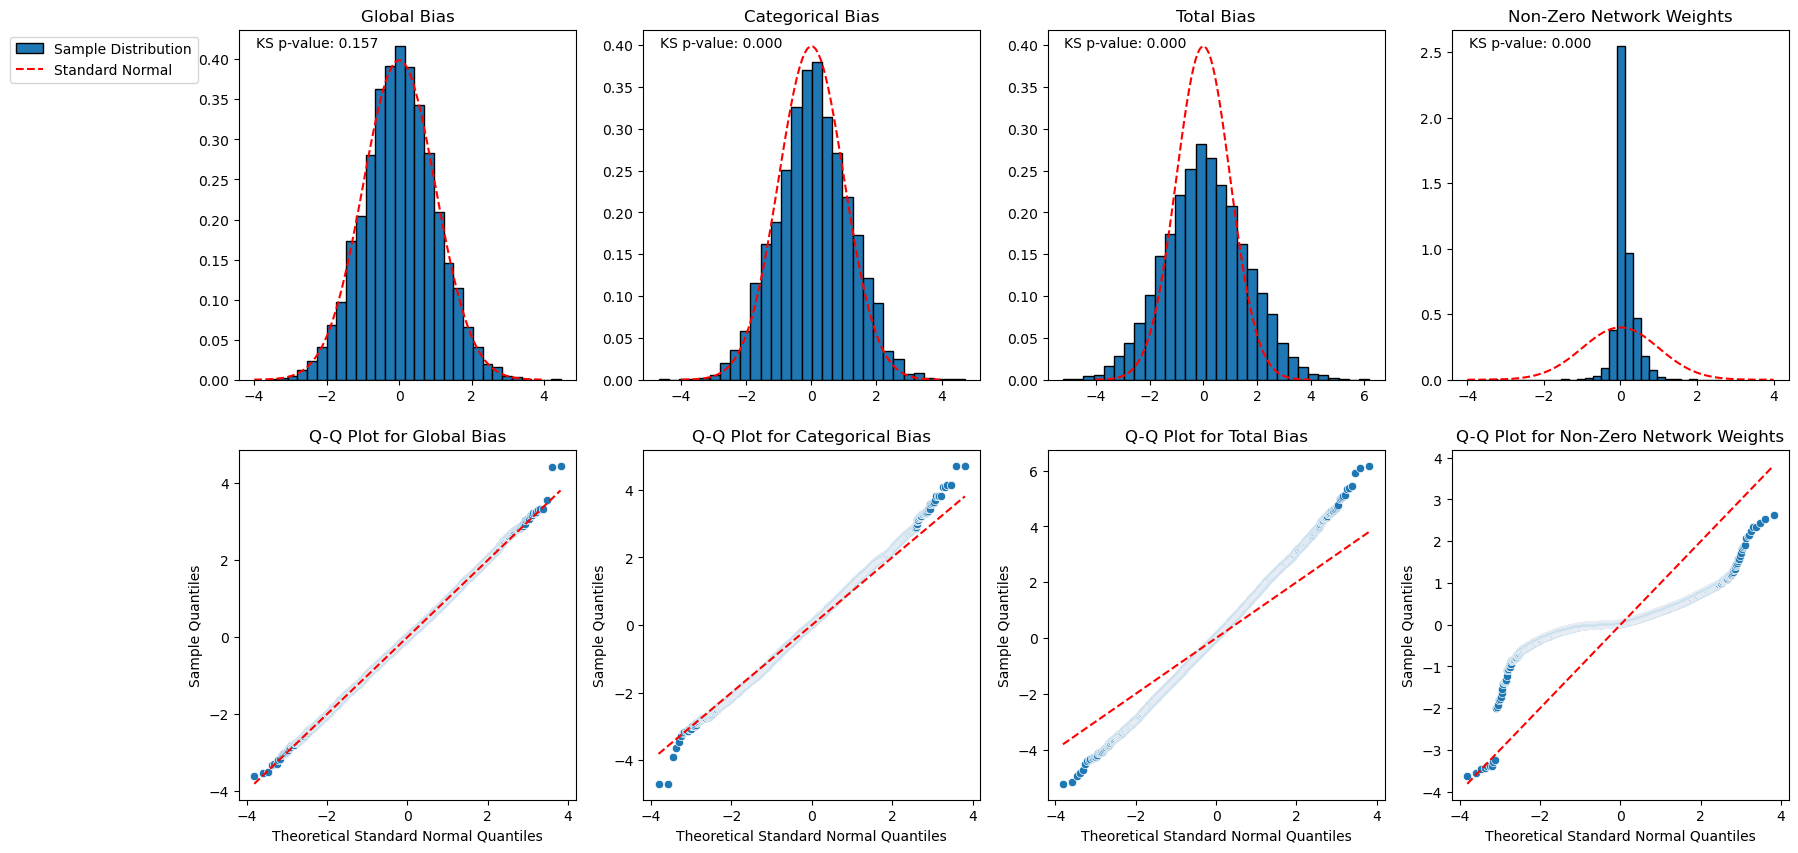

In [51]:
fig, ax = plt.subplots(ncols = 4, nrows = 2, figsize = (20, 10))
ax = ax.flatten()

# ------------------------GLOBAL BIAS------------------------
i = 0
bias_viz = bias_global.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
            loc='upper left', bbox_to_anchor=(-0.7, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Global Bias')


i+=4
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Global Bias')

# ------------------------CATEGORICAL BIAS------------------------
i = 1
bias_viz = bias_cats.detach().cpu().numpy().flatten() 
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.75, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Categorical Bias')

i+=4
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Categorical Bias')

# ------------------------TOTAL BIAS------------------------
i= 2
bias_viz = bias_tot.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.75, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Total Bias')

i+=4
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Total Bias')


# ------------------------Signaling Weights------------------------
i= 3
bias_viz = mod.signaling_network.weights.detach().cpu().numpy().flatten()
bias_viz = bias_viz[bias_viz != 0]
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.75, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Non-Zero Network Weights')

i+=4
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Non-Zero Network Weights')

;

The categorical embeddings has a few different versions to consider: We show all the learned embeddings (Everything - Unweighted), those cell types that fell into the test conditions (Test - Unweighted), and those that did not fall into the test conditions (Train - Unweighted). It is important to keep in mind since this isn't a condition (stimulation x cell type combination), the embeddings categorized as test were seen and learned during training. Finally, we get the embedding outputs from running the forward prediction. This is simply taking each learned embedding, and repeating it as the same number of times as there are test cells for a given condition. It is essentially the same as Test - Unweighted, but now it is weighted by the number of cells predicted in each test condition cell type.

In the plot above, we showed Predicted (Weighted Test). Below, we show all 4 versions. We expect them all to follow very similar distributions:

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))

bias = bias_cats.detach().cpu().numpy().flatten()
bias_cat_embeddings = mod.signaling_network.cat_embeddings.seurat_annotations.weight.detach().cpu().numpy()

test_ct_idx = [mod.signaling_network.cat_mapper['seurat_annotations'][ct.split('^')[1]] for ct in test_conds]
bias_cat_test = bias_cat_embeddings[test_ct_idx,:].flatten()

train_ct_idx = sorted(set(mod.signaling_network.cat_mapper['seurat_annotations'].values()).difference(test_ct_idx))
bias_cat_train = bias_cat_embeddings[train_ct_idx,:].flatten()

bias_cat_embeddings = bias_cat_embeddings.flatten()

cmd = 'Categorical Bias (Predicted (Weighted Test) | Test (Unweighted) | Train (Unweighted) | Everything (Unweighted): '
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias), np.std(bias)**2)
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_test), np.std(bias_cat_test)**2)
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_train), np.std(bias_cat_train)**2)
cmd += 'N({:.4f}, {:.4f})'.format(np.mean(bias_cat_embeddings), np.std(bias_cat_embeddings)**2)
print(cmd)

sns.kdeplot(np.random.choice(bias, 5000, replace = False), 
            ax = ax, color = 'blue', label = 'Predicted (Weighted Test)')
sns.kdeplot(bias_cat_test, 
            ax = ax, color = 'red', label = 'Test (Unweighted)')
sns.kdeplot(bias_cat_train, 
            ax = ax, color = 'green', label = 'Train (Unweighted)')
sns.kdeplot(bias_cat_embeddings, 
            ax = ax, color = 'black', label = 'Everything (Unweighted)')
ax.legend()

ax.set_xlabel('Trained Categorical Bias')

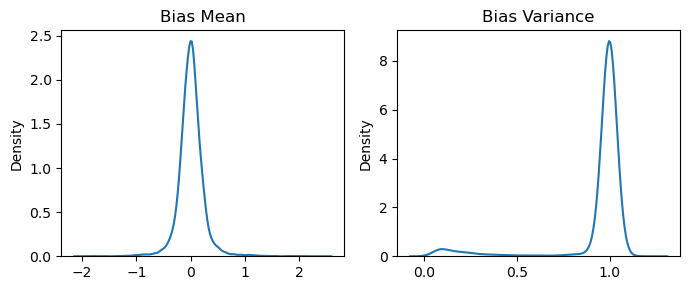

In [47]:
fig, ax = plt.subplots(ncols = 2, figsize = (7,3))
# # ------------------------Mean and Variance------------------------
i=0
bias_viz = bias_mu.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Mean')


i+=1
bias_viz = bias_sigma.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Variance')

fig.tight_layout()

Let's also visualize in distribution counterfactual. We subset to 3000 cells (in proportion to the cell types predicted) for visualization, but NMI is calculated on the entire dataset. 

In [71]:
counterfactual_type = 'in_distribution'
bias_global_na, bias_global, bias_tot, _ = biases_clustered[counterfactual_type]

In [72]:
# adata_types = ['Perfectly Separated', 'Perfectly Mixed', 
#                      'Model No Adverserial', 'Model with Adverserial', None, 
#               'Model with Adverserial - Categorical Information Added']
# adata_dict = dict(zip(adata_types, 
#                      [one_hot, rand, bias_adata_na, bias_adata, None, bias_tot]))


adata_types = ['Model No Adverserial', 'Model with Adverserial', 'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [bias_global_na, bias_global,bias_tot]))

''

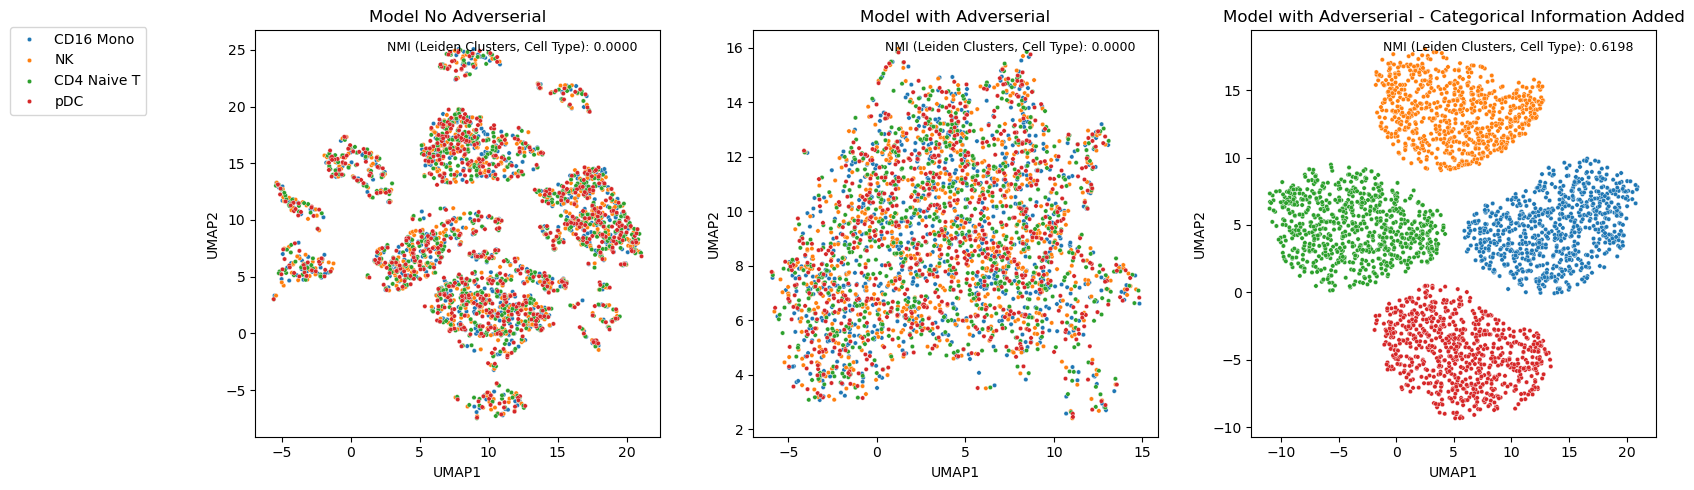

In [73]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))
ax = ax.flatten()

subset_size = 3000
for i, (adata_type, adata) in enumerate(adata_dict.items()):
    if adata is not None:
        viz_df, nmi = adata_dimviz_bias(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                             subset_size = subset_size)
        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                        s=10,
                        ax = ax[i])
        ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i].set_title(adata_type)
    else:
        ax[i].axis('off')

lines, labels = ax[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
fig.tight_layout()
;
